In [3]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import csv
from scipy import stats
# Predicted crater dimensions based on Maxwell z model
# Given ___, expect _____

# constants
g = 1.62 # m/s/s acceleration due to gravity on the moon
k = 5 # falls between .0045 and .0055 depending on crater material and explosive type & placement
z = 2.7071 # this value of z conserves vertical momentum. in practice, z falls between 2 and 4   

# display constants again
print("")
print("\033[1mConstants \033[0m")
print(f"""g = {g}m/s/s
k = {k}""")

# Simple crater calculations
print("")
print("This program predicts the size and shape of lunar impact craters based on the Maxwell z-model")
print("Simple crater dimensions (diameter < 15km on the Moon):")
r = 5 # radius
# dependent on depth
h = 2/5*r # depth
rim_h = 0.08*h
# values dependent on Z
if r <= 7.5:
    z = 2.7071
    e_h_exc = r*(z - 2)*((z - 1)**((1 - z)/(z - 2)))
    ke = (((r**(2*z + 1))*g)/(k*4*z*(z - 2))**(3/(2*z)))
    print(f"""Expected depth of the crater: {h}km
Expected height of the rim above the surrounding plain: {rim_h}km
Expected maximum excavation depth: {e_h_exc}km
Expected energy released: {ke} metric tons of TNT""")
else:
    print("This is not a simple crater")



Constants 
g = 1.62m/s/s
k = 5

This program predicts the size and shape of lunar impact craters based on the Maxwell z-model
Simple crater dimensions (diameter < 15km on the Moon):
Expected depth of the crater: 2.0km
Expected height of the rim above the surrounding plain: 0.16km
Expected maximum excavation depth: 0.9721313631969221km
Expected energy released: 6541.873398937431 metric tons of TNT


   impactor     crater  maximum excavation
0       1.0   3.636446            1.767552
1       3.5  10.469423            5.088827
2       6.0  16.501043            8.020591
3       8.5  22.140929           10.761946
4      11.0  27.524056           13.378499
5      13.5  32.718036           15.903115
6      16.0  37.763294           18.355441
7      18.5  42.686603           20.748493
cd r2: 1.0
med r2: 1.0
sim coefficients: [0.68347578 2.93240028]
sim r2: 0.7560768059974936
expected sim self: 3.017834757834758, 3.274138176638177, 4.641089743589744, 6.349779202279201, 9.767158119658118, 
sim vs cd r2: 0.7560768059974936
expected sim cd: 2.9199778684334263, 3.748289590584438, 8.165952108723165, 13.688030256396575, 24.732186551743393, 
sim vs cd r2: 0.7560768059974936
expected sim hexc: 1.419301032872518, 1.8219149346758443, 3.9691890776269183, 6.653281756315761, 12.021467113693447, 
C.D. Fit Coefficients: [2.20883126 2.64387396]
M.E.D. Fit Coefficients: [1.07363707 1.2850964 ]


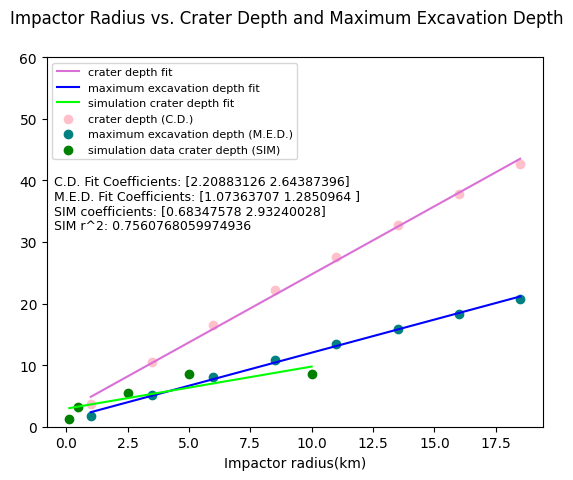

In [10]:
# output crater depth and excavation depth given impactor size

# set density constant
density = .00325 # kg/cm^3

# impactor radii in km
iradii = np.arange(1, 20, 2.5)

# preliminary calculations

# mass
masses = [] # kg
for i in iradii:
    r = i * 100000 # put radius in cm
    masses.append((4/3)*(math.pi)*(r**3)*density) # assume projectile is spherical: volume = 4/3 pi r^3

v = 10000 # assume velocity is constant 10000 m/s (10 km/s)

# kinetic energy
kes = [] # Joules
for i in masses:
    kes.append((1/2)*i*(v**2)) # ke = 1/2 m v^2

# final transient crater radii
# using equation #1 (eq 12 in maxwell 1977)
cradii = [] # km
for e in kes:
    cradii.append((k*(4*z*(z - 2)*((e*2.39006e-10)**(2*z/3))/g)**(1/(2*z + 1)))/1000)
# using eq #2 (assumes k = 2.7071 and other assumptions; eq 13 in maxwell 1977)
cradii2 = [] # km
for e in kes:
    cradii2.append((k*((e*2.39006e-10)**(1/3.55))/(g**(1/6.4)))/1000)

# calculate data to go in the csv
# crater depth
cdepths = [] # km
for r in cradii:
    cdepths.append(2/5*r)

# excavation depth
h_excs = [] # km
for r in cradii:
    h_excs.append(r*(z - 2)*((z - 1)**((1 - z)/(z - 2))))

# create list
data = [["impactor", "crater", "maximum excavation"]]
for i in range(len(iradii)):
    data.append([iradii[i], cdepths[i], h_excs[i]])

# Simulation data
sim_r = [0.125, 0.5, 2.5, 5, 10]
sim_h = [1.3, 3.25, 5.5, 8.5, 8.5]

# create csv
with open('radius_depth_hexc.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(data)

df = pd.read_csv('radius_depth_hexc.csv')
print(df.to_string()) 

# create linear fit for cd scatter plot
coefficientsd = np.polyfit(iradii, cdepths, 1)
f = np.poly1d(coefficientsd)
plt.plot(iradii, f(iradii), color="orchid", label="crater depth fit")

# r2 for crater depth
predicted_cd = []
for i in cdepths:
    predicted_cd.append(f(i))
cd_m, cd_b, cd_r, cd_p, cd_std_err = stats.linregress(cdepths,predicted_cd)
print(f"cd r2: {cd_r**2}")

# create linear fit for hexc scatter plot
coefficientshexc = np.polyfit(iradii, h_excs, 1)
h = np.poly1d(coefficientshexc)
plt.plot(iradii, h(iradii), color="blue", label="maximum excavation depth fit")

# r2 for max excavation depth
predicted_h_exc = []
for i in h_excs:
    predicted_h_exc.append(h(i))
h_exc_m, h_exc_b, h_exc_r, h_exc_p, h_exc_std_err = stats.linregress(h_excs,predicted_h_exc)
print(f"med r2: {h_exc_r**2}")

# create linear fit for simulation scatter plot
sim_coefficients = np.polyfit(sim_r, sim_h, 1)
j = np.poly1d(sim_coefficients)
plt.plot(sim_r, j(sim_r), color="lime", label="simulation crater depth fit")

# r2 for simulation crater depth vs self
ex_sim_self = []
for i in sim_r:
    ex_sim_self.append(j(i))
sim_m, sim_b, sim_r_val, sim_p, sim_std_err = stats.linregress(sim_h,ex_sim_self)
print(f"sim coefficients: {sim_coefficients}")
print(f"sim r2: {sim_r_val**2}")
print("expected sim self: ", end="")
for i in ex_sim_self:
    print(f"{i},", end=" ")
print("")

# r2 for simulation crater depth vs expected crater depth
ex_sim_cd = []
for i in sim_r:
    ex_sim_cd.append(f(i))
sim_cd_m, sim_cd_b, sim_cd_r, sim_cd_p, sim_cd_std_err = stats.linregress(sim_h,ex_sim_cd)
print(f"sim vs cd r2: {sim_cd_r**2}")
print("expected sim cd: ", end="")
for i in ex_sim_cd:
    print(f"{i},", end=" ")
print("")

# r2 for simulation crater depth vs expected max excavation depth
ex_sim_h_exc = []
for i in sim_r:
    ex_sim_h_exc.append(h(i))
sim_h_exc_m, sim_h_exc_b, sim_h_exc_r, sim_h_exc_p, sim_h_exc_std_err = stats.linregress(sim_h,ex_sim_h_exc)
print(f"sim vs cd r2: {sim_h_exc_r**2}")
print("expected sim hexc: ", end="")
for i in ex_sim_h_exc:
    print(f"{i},", end=" ")
print("")

# scatter plot
print(f"C.D. Fit Coefficients: {coefficientsd}\nM.E.D. Fit Coefficients: {coefficientshexc}")
plt.scatter(iradii, cdepths, color = "pink", label="crater depth (C.D.)")
plt.scatter(iradii, h_excs, color="teal", label="maximum excavation depth (M.E.D.)")
plt.scatter(sim_r, sim_h, color="green", label="simulation data crater depth (SIM)")
plt.legend(fontsize="8")
plt.suptitle("Impactor Radius vs. Crater Depth and Maximum Excavation Depth\n ")
plt.annotate(f"C.D. Fit Coefficients: {coefficientsd}\nM.E.D. Fit Coefficients: {coefficientshexc}\nSIM coefficients: {sim_coefficients}\nSIM r^2: {sim_r_val**2}", xy=(-0.5,32), fontsize="9")
plt.ylim(0, 60)
plt.xlabel("Impactor radius(km)")
plt.show()

In [ ]:
# impactor radii vs crater radii

# create scatter plot
plt.scatter(iradii, cradii, color="green")
plt.title("Impactor Radii vs. Final Transient Crater Radii")
plt.xlabel("Impactor Radii (km)")
plt.ylabel("Final Transient Crater Radii (km)")
plt.show()

Text(0.5, 1.0, 'Ratio Between Crater Depth and Crater Diameter as a Function of Crater Diameter')

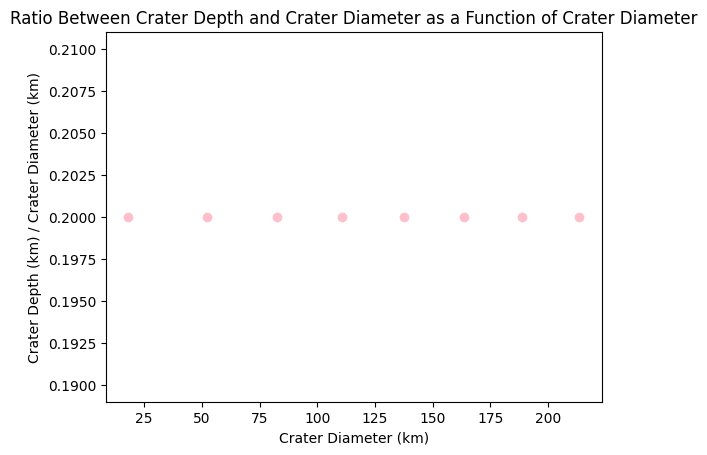

In [10]:
# ratio of crater depth to crater diameter vs. crater diameter

# crater depth/crater diameter
ch_cd_ratios = []
for i in range(len(cradii)):
    ch_cd_ratios.append(cdepths[i]/(2*cradii[i])) # diameter = 2*radii

# crater diameters
cdiameters = []
for i in range(len(cradii)):
    cdiameters.append(2*cradii[i])

# create scatter plot
plt.scatter(cdiameters, ch_cd_ratios, color="pink")
plt.xlabel("Crater Diameter (km)")
plt.ylabel("Crater Depth (km) / Crater Diameter (km)")
plt.title("Ratio Between Crater Depth and Crater Diameter as a Function of Crater Diameter")

Text(0.5, 1.0, 'Ratio Between Maximum Excavation Depth and Crater Diameter as a Function of Crater Diameter')

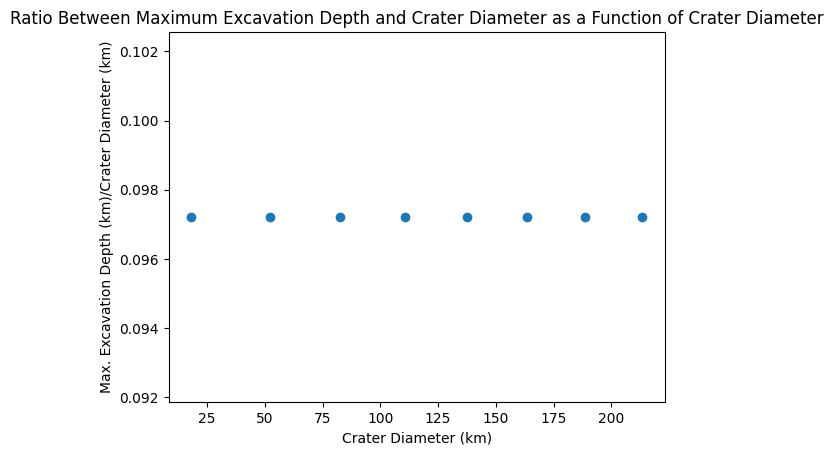

In [16]:
# ratio of maximum excavation depth to crater diameter vs. crater diameter

# maximum excavation depth/crater diameter
h_exc_cd_ratios = []
for i in range(len(cradii)):
    h_exc_cd_ratios.append(h_excs[i]/cdiameters[i])

# create scatter plot
plt.scatter(cdiameters, h_exc_cd_ratios)
plt.xlabel("Crater Diameter (km)")
plt.ylabel("Max. Excavation Depth (km)/Crater Diameter (km)")
plt.title("Ratio Between Maximum Excavation Depth and Crater Diameter as a Function of Crater Diameter")

In [ ]:
# calculate relationship between ejecta thickness and distance
